This code has been prouced as a teaching resource for the UKSA space software, data and AI course run by the Space South Central Universities.

Contributors to this code includes: O. Umeh; B. Canning; A. Tolley

---

### Learning Outcome
<div class="alert alert-block alert-info">
<b>NOTE</b> In this notebook we will learn how to access open street map data with the osmnx package.
</div>

---

### Standard Package Imports

In [3]:
# For interacting with the operating system (e.g., managing file paths)
import os

# For efficient numerical operations and array handling
import numpy as np

# For plotting, data visualization, and image manipulation
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# For downloading and analyzing OpenStreetMap (OSM) street networks
import osmnx as ox

# For encoding and decoding data in GeoJSON format
import geojson

# For working with and manipulating geospatial data
import geopandas as gpd

# For making HTTP requests to web APIs
import requests

---

### Preamble

We are interested in identifying buildings pre- and post- earthquake.

There was a 6.8 magnitude earthquake that struck the Atlas Mountains, about 75 km from Marrakech, Morocco on 8 September, 2023

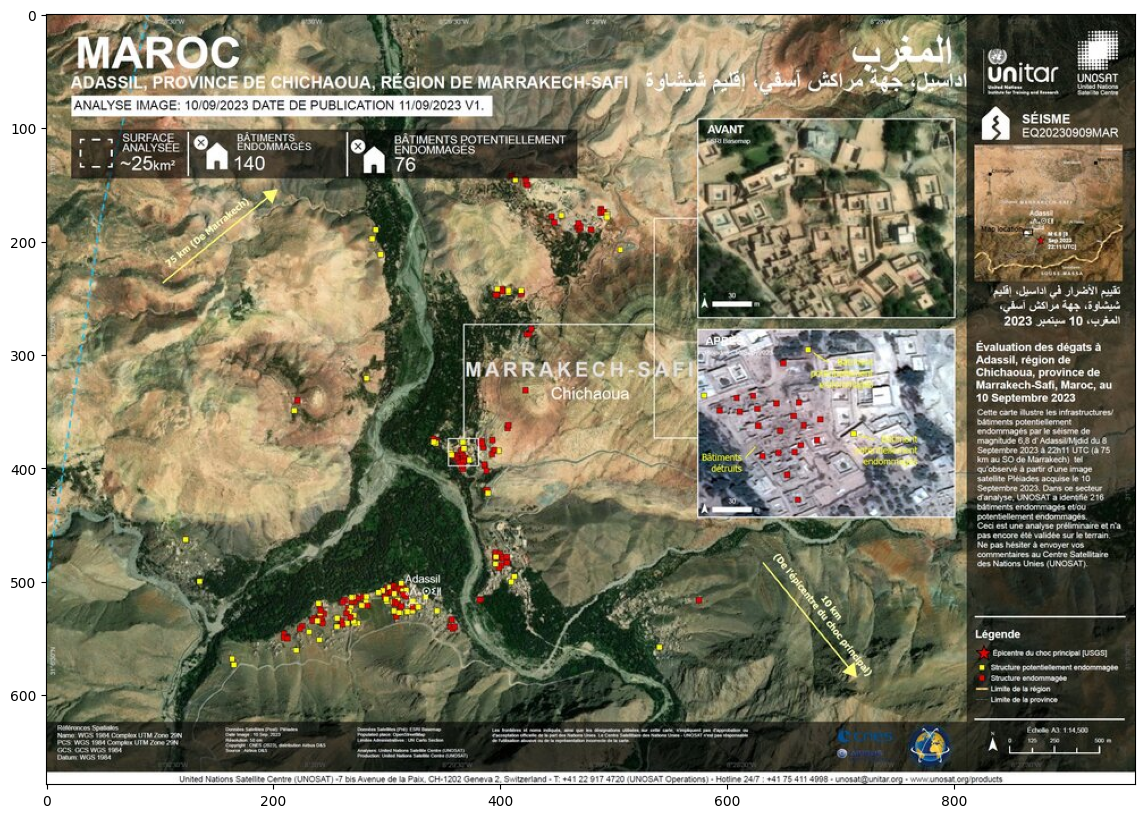

In [20]:
plt.figure(figsize=(20,10))
plt.imshow(Image.open("Morocco_earthquake_damage_assessment_map_from_the_UNOSAT_team_article.jpg"));

We can use this code for:

 * Safety and Assessment: Evaluate the stability of buildings and infrastructure.
 * Resource Allocation: Direct assistance to areas that are impacted the most.

**Our Aims**:
- Create a dataset using OpenStreetMap (OSM) polygons to annotate buildings in Sentinel-2 imagery

Deploy the skills you have learned in the course so far:

* **NOTE** Think about the data we need and its features (consult with a GIS domain expert or a disaster and risk expert etc)
* **NOTE** Think about how to approach the code and directory structures for your use case, and how and if you want generality in your application, how will you version your software appropriately and ensure that it is not 'broken' by underlying software changes, is it affordable to continue to support software updates or do you need a static solution (consult with a computational expert)
* **NOTE** Do you have other factors in deployment you need to consider e.g. cyber security, speed, accuracy, computational power, are there ethical considerations to either the data, the algorithm or the deployment, will you have liability?

1. Download required data (Recall using the `request` package)
2. Save data in a format we want (Recall using `os` and `glob` package)
3. Read in data (Recall using `rasterio` and `glob`)
4. Combine spatial data to create building masks on the same coordinate reference system (Recall using `geopandas`)
5. Augment the data for generality (multiple ways to do this, can write you own code easily enough but remember that the packages like `PyTorch` or `Tensorflow` also come with fairly quick, speed optimised solutions)
6. Write a model or load a pre-trained one (Recall how to define your models and all your tweakable parameters and hyperparameters).
7. Benchmark your models with known datasets.
8. Train your model.
9. Visualise results (Recall using `matplotlib`)
10. Test and deploy model

---

### Now we can start the project

First: define the area of interest

`osmnx` (shortened to `os` when imported) can do this with a place name - however, we have lots of examples using bounding boxes, point coordinates etc. 

In [22]:
place_name = "Marrakech, Morocco"
area_of_interest = ox.geocode_to_gdf(place_name)

Use OSM to identify the place and return a list of tagged 'buildings'

In [23]:
buildings = ox.features_from_place(place_name, tags={"building": True})

Make test plots for **EVERYTHING**, this helps with checking and debugging our code.

Let's plot the bounding box of this place name and the buildings.

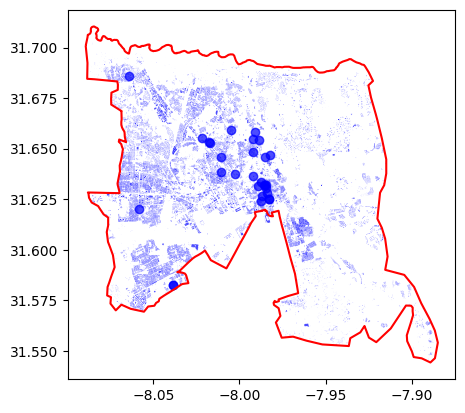

In [24]:
fig, ax = plt.subplots()
area_of_interest.boundary.plot(ax=ax, color="red")
buildings.plot(ax=ax, color="blue", alpha=0.7)
plt.show()

Save the buildings to a `geojson` file

In [25]:
buildings.to_file("marrakech_buildings.geojson", driver="GeoJSON")

Let's explore the properties of this 'buildings' geodataframe:

- Check the number of buildings

In [28]:
buildings=buildings[['geometry']] # Note: We access the buildings themselves via the `geometry` key
print(f'There are {len(buildings)} buildings in {place_name}')

There are 78128 buildings in Marrakech, Morocco


#### A little bit of jargon

**Node:** A node represents a single point on the Earth's surface. 

**Way:** A way is a sequence of connected nodes that represents a linear feature, such as a road, river, or trail

**Relations** define complex relationships between nodes and ways, representing larger features or areas

We can see examples of these in our geodataframe:


In [29]:
buildings

geometry
element id                                                           
node    1245935291                           POINT (-7.98776 31.6241)
        2620316382                            POINT (-7.984 31.62819)
        3186302961                          POINT (-8.00504 31.65929)
        3204883229                          POINT (-8.01689 31.65265)
        3211517814                          POINT (-7.99084 31.65822)
...                                                               ...
way     1396541558  POLYGON ((-7.96523 31.60811, -7.96527 31.60818...
        1396541559  POLYGON ((-7.96577 31.60793, -7.96581 31.60801...
        1396541560  POLYGON ((-7.96564 31.608, -7.96537 31.6081, -...
        1396541561  POLYGON ((-7.96613 31.6078, -7.96594 31.60787,...
        1396541562  POLYGON ((-7.96579 31.60778, -7.96552 31.60788...

[78128 rows x 1 columns]

### Exercises
- Explore the data frame
    - Use previous geopandas example to help you
    - What data is available?
    - Plot the available data
    - Look at features of the data
    - What happens if you plot `nodes` or `ways`?
- What other data can you use from OSM?
    - Google for OSM documentation
    - Ask an LLM (Like ChatGPT)
    - Pull in the complete dataframe (with no tags) of Marrakech and explore it for yourself